# Lecture 4: Hypothesis Testing and Probability

###  Hypothesis Testing + Probability

Welcome to the textbook for Lecture 4! This notebook serves as supplementary resource to help you understand the process of hypothesis testing better and learn to deduce numbers in probability at a foundational level. 

By the end of this notebook, you'll (hopefully) be able to:

- Understand and conduct hypothesis testing under the typical null-alternative framework
- Define key concepts such as p-value, type I/II error, paramaters vs statistics, and so on
- Apply basic probability rules including addition, independence, and complement to real-world situations

**Let's get started!!**

## **Part I: Hypothesis Testing:**

## 0. Setup — Our Dataset

Throughout this section, we'll work with data from **25 students** in a university statistics course. For each student, we've recorded:

| Column | Description |
|--------|-------------|
| `name` | Student's first name |
| `study_hours` | Average weekly hours spent studying (self-reported) |
| `exam_score` | Final exam score out of 100 |
| `sleep_hours` | Average nightly hours of sleep |
| `commute_min` | One-way commute time in minutes |
| `group` | Whether the student took a **free tutoring workshop** (`"workshop"`) or not (`"control"`) |

Let's load our data and take a first look.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Reproducibility
np.random.seed(42)

# ── Our 25 students ──────────────────────────────────────────────────────────
data = {
    'name':         ['Alex', 'Andre', 'Anirra', 'Aniruthan', 'Bo',
                     'Christopher', 'Gina', 'Iana', 'Kabilan', 'Nathan',
                     'Rinrada', 'Sameer', 'Sarah', 'Wayland', 'Priya',
                     'DeShawn', 'Mei', 'Luca', 'Fatima', 'Tobias',
                     'Nkechi', 'Oren', 'Soleil', 'Dmitri', 'Camille'],

    'study_hours':  [8.5, 6.0, 9.0, 11.5, 4.0,
                     7.5, 10.0, 5.5, 12.0, 6.5,
                     9.5, 8.0, 7.0, 5.0, 10.5,
                     4.5, 11.0, 6.0, 9.0, 7.5,
                     8.0, 5.5, 10.0, 6.5, 9.5],

    'exam_score':   [78, 65, 82, 91, 55,
                     74, 88, 60, 94, 67,
                     85, 76, 71, 58, 89,
                     52, 90, 63, 83, 72,
                     77, 61, 87, 66, 84],

    'sleep_hours':  [7.0, 6.5, 7.5, 6.0, 8.0,
                     7.0, 6.5, 7.5, 6.0, 7.0,
                     7.0, 6.5, 8.0, 7.5, 6.5,
                     8.5, 6.0, 7.0, 7.5, 6.5,
                     7.0, 8.0, 6.5, 7.0, 7.5],

    'commute_min':  [20, 45, 10, 5, 60,
                     30, 15, 50, 8, 35,
                     12, 25, 40, 55, 10,
                     65, 7, 38, 18, 28,
                     22, 48, 14, 32, 20],

    # First 13 students attended the workshop; the last 12 are the control group
    'group':        ['workshop'] * 13 + ['control'] * 12
}

df = pd.DataFrame(data)
print(f"Dataset shape: {df.shape}")
df

Dataset shape: (25, 6)


,name,study_hours,exam_score,sleep_hours,commute_min,group
0,Alex,8.5,78,7.0,20,workshop
1,Andre,6.0,65,6.5,45,workshop
2,Anirra,9.0,82,7.5,10,workshop
3,Aniruthan,11.5,91,6.0,5,workshop
4,Bo,4.0,55,8.0,60,workshop
5,Christopher,7.5,74,7.0,30,workshop
6,Gina,10.0,88,6.5,15,workshop
7,Iana,5.5,60,7.5,50,workshop
8,Kabilan,12.0,94,6.0,8,workshop
9,Nathan,6.5,67,7.0,35,workshop


---

## 1. The Big Question — And Why We Need a Framework

Look at the `group` column. Half our students attended a **free tutoring workshop** before the final exam; the other half did not. The instructor wants to know:

> **Did the workshop actually help students score higher on the exam?**

Let's peek at the average scores for each group first.

In [3]:
workshop_scores = df[df['group'] == 'workshop']['exam_score']
control_scores  = df[df['group'] == 'control']['exam_score']

print(f"Workshop group  — n={len(workshop_scores)}, mean={workshop_scores.mean():.2f}, std={workshop_scores.std():.2f}")
print(f"Control group   — n={len(control_scores)},  mean={control_scores.mean():.2f}, std={control_scores.std():.2f}")
print(f"\nObserved difference in means (workshop − control): {workshop_scores.mean() - control_scores.mean():.2f} points")

Workshop group  — n=13, mean=75.85, std=12.05
Control group   — n=12,  mean=73.50, std=13.26

Observed difference in means (workshop − control): 2.35 points


The workshop group's average is higher — but here's the crucial question: **is that difference real, or could it have happened by chance?**

Imagine randomly splitting any 25 students into two groups with no workshop at all. Sometimes, purely by the luck of who ends up in which group, one group will happen to have higher scorers. We need a way to distinguish a **genuine effect** from **random noise**.

That's exactly what hypothesis testing is designed to do.

---

## 2. Null and Alternative Hypotheses

Every hypothesis test starts by stating two competing claims about the world.

---

### 2.1 The Null Hypothesis $H_0$ — The Skeptic's Claim

The **null hypothesis** ($H_0$) is the *default* position of skepticism. It says: **nothing interesting is going on**. Any pattern you see in the data is just random variation.

For our workshop question:

$$H_0: \mu_{\text{workshop}} = \mu_{\text{control}}$$

In plain English: *"The workshop has no effect. The two groups' exam score means are equal in the population. The difference we observed is just chance."*

---

### 2.2 The Alternative Hypothesis $H_A$ — The Researcher's Claim

The **alternative hypothesis** ($H_A$, also written $H_1$) is what we'd conclude if the null is rejected. It represents the signal we're trying to detect.

$$H_A: \mu_{\text{workshop}} > \mu_{\text{control}}$$

In plain English: *"The workshop does help. Students who attended it score higher, on average."*

> **One-sided vs. two-sided tests.** Our alternative is *one-sided* (we're only looking for an increase). A *two-sided* alternative would be $\mu_{\text{workshop}} \neq \mu_{\text{control}}$ — useful when you don't know the direction of the effect beforehand. For this section, we'll use a one-sided test.

---

**Why do we frame it this way?** Notice that we never try to *prove* $H_A$ directly. Instead, we ask: *"How likely is it to see data this extreme if $H_0$ were true?"* If the answer is "very unlikely," we have reason to doubt $H_0$ and favor $H_A$. This asymmetry is fundamental — and we'll return to it at the end.

---

## 3. The Test Statistic — Turning Data into a Single Number

We need a single number that **summarizes how different the two groups look**. This is called the **test statistic**.

For a comparison of two group means, a natural choice is:

$$\text{test statistic} = \bar{X}_{\text{workshop}} - \bar{X}_{\text{control}}$$

This is the **observed difference in means** — positive if the workshop group scored higher, negative if they scored lower, and zero if the groups were identical.

> **Why not just look at the raw numbers?** A difference of 5 points means something very different if exam scores range from 0–10 versus 0–100, or if there are 5 students per group versus 500. The test statistic packages the signal into a form we can reason about precisely.

Let's compute ours.

In [4]:
observed_diff = workshop_scores.mean() - control_scores.mean()
print(f"Observed test statistic (difference in means): {observed_diff:.4f} points")
print()
print(f"  Workshop mean : {workshop_scores.mean():.4f}")
print(f"  Control mean  : {control_scores.mean():.4f}")
print(f"  Difference    : {observed_diff:.4f}")

Observed test statistic (difference in means): 2.3462 points

  Workshop mean : 75.8462
  Control mean  : 73.5000
  Difference    : 2.3462


---

## 4. Bootstrapping — Building a Reference Distribution Under $H_0$

Here's the core idea: **if the workshop had no effect**, then the group assignment (`workshop` vs `control`) is arbitrary. Any random split of our 25 students into groups of 13 and 12 would be just as valid as the one we observed.

So we can *simulate* what $H_0$ looks like by:

1. **Pooling** all 25 exam scores together (ignoring group labels).
2. **Randomly re-assigning** group labels — shuffling who is "workshop" and who is "control".
3. **Computing** the difference in means for this new fake assignment.
4. **Repeating** this process thousands of times to build a distribution of differences under $H_0$.

This distribution is called the **null distribution** or **bootstrap distribution under $H_0$**. It tells us: *"How spread out are the differences in means when there is truly no effect?"*

> **Why is this valid?** Under $H_0$, the group labels carry no information — so permuting them doesn't change the underlying reality. We're sampling from the null world.

Let's run the simulation.

In [5]:
n_workshop = len(workshop_scores)   # 13
all_scores  = df['exam_score'].values
n_bootstrap = 10_000

null_diffs = []

for _ in range(n_bootstrap):
    # Shuffle all scores and split into fake groups
    shuffled = np.random.permutation(all_scores)
    fake_workshop = shuffled[:n_workshop]
    fake_control  = shuffled[n_workshop:]
    null_diffs.append(fake_workshop.mean() - fake_control.mean())

null_diffs = np.array(null_diffs)
print(f"Null distribution: mean={null_diffs.mean():.4f}, std={null_diffs.std():.4f}")
print(f"Observed test statistic: {observed_diff:.4f}")

Null distribution: mean=0.0512, std=4.9577
Observed test statistic: 2.3462


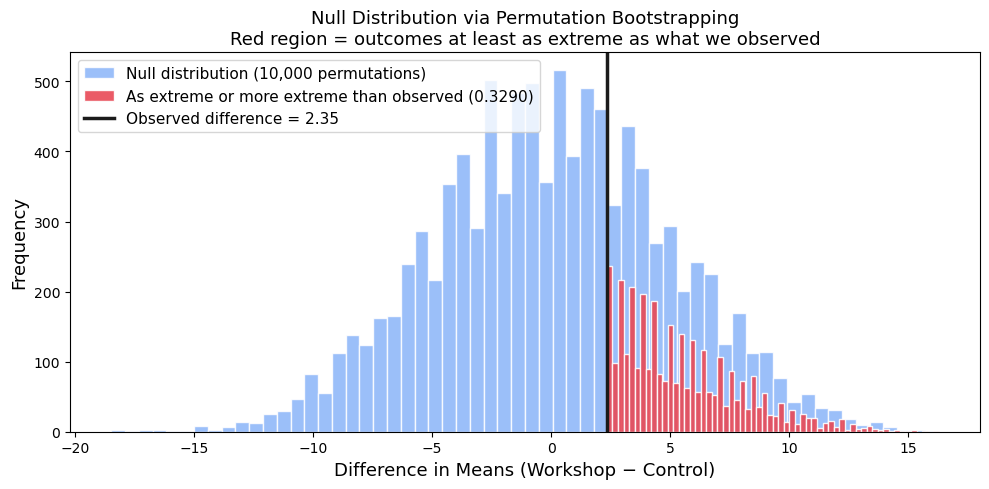

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(null_diffs, bins=60, color='#8AB4F8', edgecolor='white', alpha=0.85,
        label='Null distribution (10,000 permutations)')

# Shade the region at least as extreme as our observed statistic
extreme = null_diffs[null_diffs >= observed_diff]
ax.hist(extreme, bins=60, color='#E84855', edgecolor='white', alpha=0.90,
        label=f'As extreme or more extreme than observed ({len(extreme)/n_bootstrap:.4f})')

ax.axvline(observed_diff, color='#1B1B1B', linestyle='-', linewidth=2.5,
           label=f'Observed difference = {observed_diff:.2f}')

ax.set_xlabel('Difference in Means (Workshop − Control)', fontsize=13)
ax.set_ylabel('Frequency', fontsize=13)
ax.set_title('Null Distribution via Permutation Bootstrapping\n'
             'Red region = outcomes at least as extreme as what we observed', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

The histogram above is the null distribution — the range of differences we'd expect **by chance alone** if the workshop had no effect.

Notice that:
- It's centred near **0** (as expected — no effect means no systematic difference).
- Most differences fall between roughly **−8 and +8**.
- Our observed statistic is marked by the black vertical line.

The red region shows how often random chance produces a result at least as large as ours. That proportion is the **p-value**.

---

## 5. The P-Value — Quantifying Surprise

### 5.1 Definition

The **p-value** is the probability of obtaining a test statistic **at least as extreme as the one we observed**, assuming $H_0$ is true.

$$p\text{-value} = P(\text{test statistic} \geq \text{observed} \mid H_0 \text{ is true})$$

It answers the question: *"If the workshop truly had no effect, how often would random chance alone produce a gap this large (or larger)?"*

- A **small p-value** means: "It would be very unusual to see this result by chance." → Evidence against $H_0$.
- A **large p-value** means: "This result is pretty normal even under $H_0$." → No strong evidence against $H_0$.

> ⚠️ **Common misconception:** The p-value is **not** the probability that $H_0$ is true. It's the probability of the *data* (or more extreme data), given that $H_0$ is true. This distinction matters enormously.

### 5.2 The Significance Cutoff $\alpha$ — Drawing the Line

A p-value alone doesn't tell us what *decision* to make. We need a threshold — a pre-agreed level of evidence — below which we'll reject $H_0$. This threshold is called the **significance level**, denoted $\alpha$.

The two most common choices are:

| $\alpha$ | Meaning |
|----------|---------|
| **0.05** | We accept up to a 5% chance of wrongly rejecting $H_0$ |
| **0.01** | We accept only a 1% chance — a stricter standard |

The choice of $\alpha$ should be made **before looking at the data** to avoid "p-hacking" — unconsciously choosing a threshold that makes your result look significant.

> **Why 0.05?** It's a convention (credited to Ronald Fisher, 1920s) — not a law of nature. Some fields, like particle physics, use thresholds as small as $5 \times 10^{-7}$ because the cost of a false positive is enormous. Always think about what $\alpha$ is appropriate for your context.

For our test, let's set $\alpha = 0.05$.

In [9]:
p_value = np.mean(null_diffs >= observed_diff)
print(f"p-value = {p_value:.4f}")
print()
print(f"Interpretation: If the workshop had zero effect, random chance would produce")
print(f"a difference as large as {observed_diff:.2f} points about {p_value*100:.1f}% of the time.")

alpha = 0.05

print(f"Significance level  : α = {alpha}")
print(f"p-value             : {p_value:.4f}")
print(f"p-value < α?        : {p_value < alpha}")
print()
if p_value < alpha:
    print("→ p-value is BELOW the significance threshold.")
    print("  We have sufficient evidence to REJECT H₀.")
else:
    print("→ p-value is ABOVE the significance threshold.")
    print("  We FAIL TO REJECT H₀.")

p-value = 0.3290

Interpretation: If the workshop had zero effect, random chance would produce
a difference as large as 2.35 points about 32.9% of the time.
Significance level  : α = 0.05
p-value             : 0.3290
p-value < α?        : False

→ p-value is ABOVE the significance threshold.
  We FAIL TO REJECT H₀.


## **Part II: Probability**

---

## 1. The Basics — What Is a Probability?

The **probability** of an event $A$ is a number between 0 and 1 that represents how likely $A$ is to occur:

$$0 \leq P(A) \leq 1$$

- $P(A) = 0$ → $A$ is **impossible**
- $P(A) = 1$ → $A$ is **certain**
- $P(A) = 0.5$ → $A$ is equally likely to happen or not

The **sample space** $S$ is the set of all possible outcomes. By definition:

$$P(S) = 1$$

**Example:** Roll a fair six-sided die. The sample space is $S = \{1, 2, 3, 4, 5, 6\}$. Each outcome has probability $\frac{1}{6}$.

---

## 2. Core Rules of Probability

### 2.1 The Complement Rule

The **complement** of $A$, written $A^c$ (or $\bar{A}$), is the event that $A$ does *not* happen. Since either $A$ happens or it doesn't:

$$\boxed{P(A^c) = 1 - P(A)}$$

**Example:** The probability of rain tomorrow is 0.3. What's the probability it *doesn't* rain?

$$P(\text{no rain}) = 1 - 0.3 = 0.7$$

Simple — but surprisingly useful. It's often much easier to calculate $P(A^c)$ and subtract than to calculate $P(A)$ directly (e.g., *"probability of rolling at least one 6 in three rolls"*).

---

### 2.2 The Addition Rule

What's the probability that event $A$ **or** event $B$ occurs?

$$\boxed{P(A \cup B) = P(A) + P(B) - P(A \cap B)}$$

The last term subtracts the **overlap** — otherwise, outcomes in both $A$ and $B$ would be counted twice.

**Special case — mutually exclusive events:** If $A$ and $B$ cannot both happen at the same time ($P(A \cap B) = 0$), the formula simplifies to:

$$P(A \cup B) = P(A) + P(B)$$

**Example:** Draw one card from a standard deck.
- $P(\text{Heart}) = 13/52 = 0.25$
- $P(\text{King}) = 4/52 \approx 0.077$
- $P(\text{Heart AND King}) = 1/52 \approx 0.019$ (the King of Hearts)
- $P(\text{Heart OR King}) = 0.25 + 0.077 - 0.019 = 0.308$

### 2.3 The Multiplication Rule & Conditional Probability

What's the probability that **both** $A$ and $B$ occur? The answer depends on whether the events influence each other.

First, we need **conditional probability** — the probability of $A$ *given that* $B$ has already occurred:

$$\boxed{P(A \mid B) = \frac{P(A \cap B)}{P(B)}}$$

Rearranging gives the **general multiplication rule**:

$$\boxed{P(A \cap B) = P(B) \cdot P(A \mid B)}$$

**Example:** A bag has 5 red and 3 blue marbles. You draw two marbles **without replacement**.
- $P(\text{1st is red}) = 5/8$
- $P(\text{2nd is red} \mid \text{1st was red}) = 4/7$ — only 4 red marbles remain
- $P(\text{both red}) = \frac{5}{8} \times \frac{4}{7} = \frac{20}{56} \approx 0.357$

---

## 3. Independence and Dependence

### 3.1 Independent Events

Two events are **independent** if knowing that one occurred tells you **nothing** about whether the other occurred. Formally:

$$\boxed{A \perp B \iff P(A \mid B) = P(A)}$$

Equivalently, for independent events the multiplication rule simplifies beautifully:

$$P(A \cap B) = P(A) \cdot P(B)$$

**Example:** Flip a fair coin twice. The outcome of the first flip has zero influence on the second.
- $P(\text{Heads on flip 1}) = 0.5$
- $P(\text{Heads on flip 2}) = 0.5$
- $P(\text{both Heads}) = 0.5 \times 0.5 = 0.25$ ✓

---

### 3.2 Dependent Events

Events are **dependent** when the occurrence of one *changes the probability* of the other. This is the case any time sampling is done **without replacement**, or when there's a real causal/associative link between events.

**Example (medical):** Let $D$ = "patient has a disease" and $T$ = "test comes back positive." These are clearly dependent — a positive test is far more likely when the disease is present. $P(T \mid D) \gg P(T \mid D^c)$.

---

In [12]:
# Illustration: independent vs. dependent
# Scenario: 1000 students, tracked on two binary variables

n = 1000

# --- INDEPENDENT case ---
# Likes coffee (40% of all students) and owns a bike (30% of all students)
# These are unrelated
coffee = np.random.rand(n) < 0.40
bike   = np.random.rand(n) < 0.30   # drawn independently

p_coffee     = coffee.mean()
p_bike       = bike.mean()
p_both_ind   = (coffee & bike).mean()
p_product    = p_coffee * p_bike

print("── INDEPENDENT events ──────────────────────────")
print(f"  P(Coffee)               = {p_coffee:.3f}")
print(f"  P(Bike)                 = {p_bike:.3f}")
print(f"  P(Coffee AND Bike)      = {p_both_ind:.3f}")
print(f"  P(Coffee) × P(Bike)     = {p_product:.3f}")
print(f"  Close to equal? → {'YES ✓' if abs(p_both_ind - p_product) < 0.03 else 'NO ✗'}")

# --- DEPENDENT case ---
# Studies a lot (50%) and scores well (but scoring depends on studying!)
studies_hard = np.random.rand(n) < 0.50
# Students who study hard score well 80% of the time; others only 30%
scores_well  = np.where(studies_hard,
                        np.random.rand(n) < 0.80,
                        np.random.rand(n) < 0.30)

p_study      = studies_hard.mean()
p_score      = scores_well.mean()
p_both_dep   = (studies_hard & scores_well).mean()
p_product2   = p_study * p_score

print()
print("── DEPENDENT events ─────────────────────────────")
print(f"  P(Studies Hard)                   = {p_study:.3f}")
print(f"  P(Scores Well)                    = {p_score:.3f}")
print(f"  P(Studies Hard AND Scores Well)   = {p_both_dep:.3f}")
print(f"  P(Studies) × P(Scores)            = {p_product2:.3f}")
print(f"  Close to equal? → {'YES' if abs(p_both_dep - p_product2) < 0.03 else 'NO ✗  (events are dependent!)'}")

── INDEPENDENT events ──────────────────────────
  P(Coffee)               = 0.379
  P(Bike)                 = 0.286
  P(Coffee AND Bike)      = 0.109
  P(Coffee) × P(Bike)     = 0.108
  Close to equal? → YES ✓

── DEPENDENT events ─────────────────────────────
  P(Studies Hard)                   = 0.487
  P(Scores Well)                    = 0.533
  P(Studies Hard AND Scores Well)   = 0.378
  P(Studies) × P(Scores)            = 0.260
  Close to equal? → NO ✗  (events are dependent!)


---

## 4. Bayes' Rule — Updating Beliefs with Evidence

This is arguably the most important formula in all of probability. Bayes' Rule tells us how to **update** our belief about something after observing new evidence.

$$\boxed{P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}}$$

Let's name each piece:

| Term | Name | Meaning |
|------|------|---------|
| $P(A)$ | **Prior** | Our belief in $A$ *before* seeing $B$ |
| $P(B \mid A)$ | **Likelihood** | How probable is the evidence $B$ if $A$ is true? |
| $P(B)$ | **Marginal** | Total probability of seeing $B$ (under all scenarios) |
| $P(A \mid B)$ | **Posterior** | Our updated belief in $A$ *after* seeing $B$ |

---

### 4.1 The Classic Example — Medical Testing

Suppose a disease affects **1% of the population**. There's a test for it with the following properties:
- **Sensitivity** (true positive rate): $P(\text{test}^+ \mid \text{disease}) = 0.99$
- **Specificity** (true negative rate): $P(\text{test}^- \mid \text{no disease}) = 0.95$, which means the **false positive rate** is $P(\text{test}^+ \mid \text{no disease}) = 0.05$

You test **positive**. What is the probability you actually have the disease?

Most people's gut says: *"The test is 99% accurate — so probably 99%?"*

Let's compute it properly.

In [14]:
# Bayes' Rule — Medical Test
P_disease       = 0.01          # Prior: 1% prevalence
P_pos_given_D   = 0.99          # Sensitivity
P_pos_given_noD = 0.05          # False positive rate
P_no_disease    = 1 - P_disease

# Total probability of a positive test (law of total probability)
P_pos = P_pos_given_D * P_disease + P_pos_given_noD * P_no_disease

# Bayes' Rule
P_disease_given_pos = (P_pos_given_D * P_disease) / P_pos

print("Bayes' Rule — Medical Test")
print("-" * 42)
print(f"  Prior P(disease)                    = {P_disease:.2f}")
print(f"  Sensitivity P(+ | disease)          = {P_pos_given_D:.2f}")
print(f"  False positive P(+ | no disease)    = {P_pos_given_noD:.2f}")
print(f"  P(positive test) [marginal]         = {P_pos:.4f}")
print()
print(f"  Posterior P(disease | positive test) = {P_disease_given_pos:.4f}  ({P_disease_given_pos*100:.1f}%)")

Bayes' Rule — Medical Test
------------------------------------------
  Prior P(disease)                    = 0.01
  Sensitivity P(+ | disease)          = 0.99
  False positive P(+ | no disease)    = 0.05
  P(positive test) [marginal]         = 0.0594

  Posterior P(disease | positive test) = 0.1667  (16.7%)


**Only ~16.7%!** Despite a test that's 99% sensitive, a positive result means you only have about a 1-in-6 chance of actually having the disease. Why?

Because the disease is **rare** (1% prevalence). Most people who test positive are false positives from the healthy majority. The low prior drowns out the high sensitivity.

This is called the **base rate fallacy** — ignoring the prior $P(A)$ when updating beliefs. Bayes' Rule prevents this mistake by forcing us to account for the prior explicitly.

Let's visualise this with 10,000 simulated people to make it concrete.

Out of 10,000 people:
  True positives  (have disease, test +) : 90
  False positives (no disease,  test +)  : 534
  Total positives                        : 624
  P(disease | positive) ≈ 90/624 = 0.144


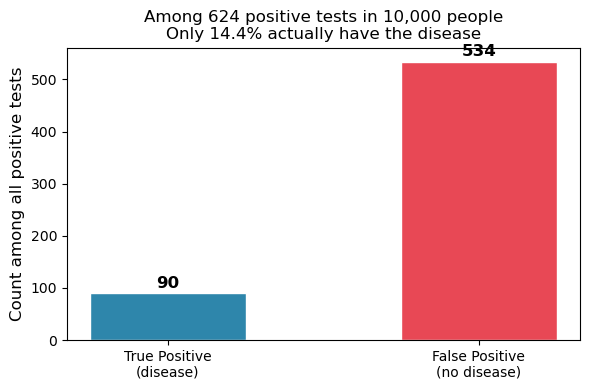

In [15]:
# Simulate 10,000 people
N = 10_000
has_disease = np.random.rand(N) < P_disease

tests_positive = np.where(
    has_disease,
    np.random.rand(N) < P_pos_given_D,
    np.random.rand(N) < P_pos_given_noD
)

true_pos  = (has_disease  & tests_positive).sum()
false_pos = (~has_disease & tests_positive).sum()
total_pos = tests_positive.sum()

print(f"Out of {N:,} people:")
print(f"  True positives  (have disease, test +) : {true_pos}")
print(f"  False positives (no disease,  test +)  : {false_pos}")
print(f"  Total positives                        : {total_pos}")
print(f"  P(disease | positive) ≈ {true_pos}/{total_pos} = {true_pos/total_pos:.3f}")

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['True Positive\n(disease)', 'False Positive\n(no disease)'],
       [true_pos, false_pos],
       color=['#2E86AB', '#E84855'], edgecolor='white', width=0.5)
ax.set_ylabel('Count among all positive tests', fontsize=12)
ax.set_title(f'Among {total_pos} positive tests in {N:,} people\nOnly {true_pos/total_pos*100:.1f}% actually have the disease', fontsize=12)
for i, v in enumerate([true_pos, false_pos]):
    ax.text(i, v + 10, str(v), ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Bayes' Rule — Updating with Multiple Pieces of Evidence

One elegant property of Bayes' Rule: you can apply it **sequentially**. The posterior from one update becomes the prior for the next.

Using our medical test: suppose you test positive **twice**, independently.

- After 1st positive test: $P(\text{disease}) \approx 0.167$ (our posterior above)
- Use **that** as the new prior, apply Bayes again with the 2nd positive result:

  After positive test #1: P(disease) = 0.1667 (16.7%)
  After positive test #2: P(disease) = 0.7984 (79.8%)


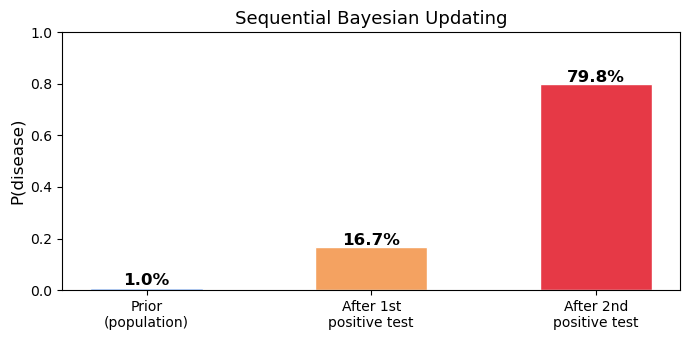

In [16]:
priors = [P_disease]  # start with population prevalence
posteriors = []

for test_result in ['positive', 'positive']:
    prior = priors[-1]
    p_evidence = P_pos_given_D * prior + P_pos_given_noD * (1 - prior)
    posterior  = (P_pos_given_D * prior) / p_evidence
    posteriors.append(posterior)
    priors.append(posterior)
    print(f"  After {test_result} test #{len(posteriors)}: P(disease) = {posterior:.4f} ({posterior*100:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 3.5))
stages = ['Prior\n(population)', 'After 1st\npositive test', 'After 2nd\npositive test']
values = [P_disease, posteriors[0], posteriors[1]]
colors = ['#8AB4F8', '#F4A261', '#E63946']
bars = ax.bar(stages, values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val*100:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('P(disease)', fontsize=12)
ax.set_title('Sequential Bayesian Updating', fontsize=13)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()